## SMOTE(Synthetic Minority Oversampling Technique)
SMOTE (Synthetic Minority Over-sampling Technique) is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class.

So in upsampling the issue is the variance is not increasing with the data points , data points are overelapped where it already existed. To counter this we create synthetic data with interpolation techniques by trying to connect 2 different and nearest data points and adds new data points on the line , therefore the new data has variance.


In [6]:
from sklearn.datasets import make_classification

In [7]:
x,y = make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,weights=[0.9],random_state=12,n_redundant=0)

In [8]:
import pandas as pd
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
final_df = pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [9]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

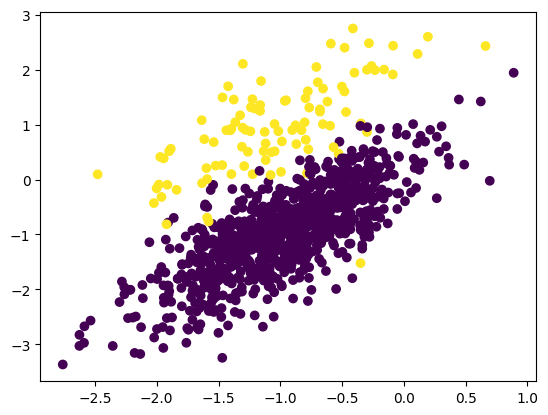

In [10]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [11]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE()
x,y = oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [15]:
x.shape,y.shape

((1800, 2), (1800,))

In [17]:
len(y[y==0]),len(y[y==1])

(900, 900)

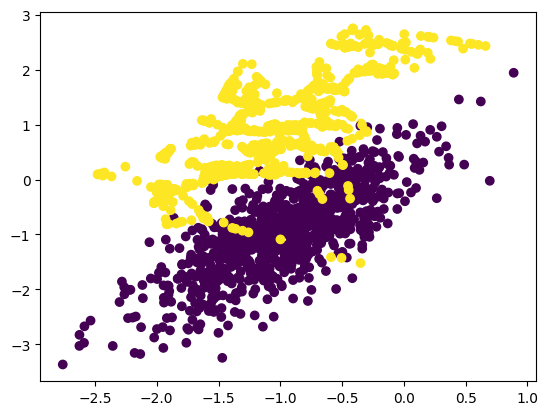

In [19]:
df1 = pd.DataFrame(x,columns=['f1','f2'])
df2 = pd.DataFrame(y,columns=['target'])
oversampled_dataframe = pd.concat([df1,df2],axis=1)
plt.scatter(oversampled_dataframe['f1'],oversampled_dataframe['f2'],c=oversampled_dataframe['target'])